# f6_m02b_dice.ipynb
**TFM: Pronóstico del Éxito y del Abandono en los Títulos de Grado de la UJI**

| | |
|---|---|
| **Autora** | María José Morte Ruiz |
| **Institución** | UOC + Universitat Jaume I |
| **Email** | mjmorteruiz@uoc.edu · morte@uji.es |
| **Fase** | 6 — Interpretabilidad y Evaluación Final |
| **Módulo** | M02b — Contrafactuales DiCE |

---

## 🎯 Qué hace

Genera explicaciones contrafactuales con DiCE (Microsoft): dado un alumno
predicho como abandono, ¿qué cambios mínimos harían que el modelo predijera no-abandono?

**Mejora cum laude:** distingue entre features accionables (la universidad PUEDE
intervenir) y no accionables (características fijas del alumno). Solo los
contrafactuales accionables son útiles para política institucional real.

## 📋 Requisitos

- `data/05_modelado/X_test_prep.parquet`
- `data/05_modelado/X_train_prep.parquet`
- `data/05_modelado/y_test.parquet`
- `data/05_modelado/y_train.parquet`
- `data/05_modelado/models/CatBoost__balanced.pkl`
- `src/config_entorno.py` — NOMBRES_LEGIBLES_FEATURES
- Paquete: dice-ml

## 📤 Genera

| Archivo | Contenido |
|---|---|
| `results/fase6/dice_contrafactuales.parquet` | Tabla contrafactuales (cache validado) |
| `results/fase6/dice_contrafactuales_meta.json` | Metadatos cache |
| `results/fase6/dice_{perfil}.png` | Gráfico original vs contrafactual (×3) |
| `results/fase6/dice_accionables.png` | 🏆 Ranking de features accionables por coste |
| `docs/html/fase6/m02b_dice.html` | Informe HTML |

## 🔄 Flujo

```
X_train_prep + X_test_prep + CatBoost
    ↓ Clasificar features: accionables vs no accionables
    ↓ DiCE: solo modifica features accionables
    ↓ Cache validado: cargar o recalcular
    ↓ Gráfico comparativo + ranking accionables
    → parquet + m02b_dice.html
```

## ➡️ Siguiente

`f6_m03_fairness_indice.ipynb`


In [1]:
# ============================================================
# CELDA 1: CONFIGURACIÓN DE RUTAS
# ============================================================
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

DIR_DATA    = ROOT / 'data' / '05_modelado'
DIR_MODELS  = DIR_DATA / 'models'
DIR_RESULTS = ROOT / 'results' / 'fase6'
DIR_HTML    = ROOT / 'docs' / 'html' / 'fase6'
DIR_RESULTS.mkdir(parents=True, exist_ok=True)
DIR_HTML.mkdir(parents=True, exist_ok=True)

print(f'ROOT:       {ROOT}')
print(f'DIR_RESULTS:{DIR_RESULTS}')

ROOT:       C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_RESULTS:C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# ============================================================
# CELDA 2: IMPORTS
# ============================================================
import json
import hashlib
import base64
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import dice_ml
from dice_ml import Dice
from src.html.render import render_pagina_desde_fichero
from src.config_entorno import NOMBRES_LEGIBLES_FEATURES

matplotlib.rcParams['figure.dpi'] = 120

def nombre_legible(f: str) -> str:
    return NOMBRES_LEGIBLES_FEATURES.get(f, f.replace('_', ' '))

print('Imports OK.')

Imports OK.


In [3]:
# ============================================================
# CELDA 3: CARGAR DATOS Y MODELO
# ============================================================
X_test_prep  = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')
X_train_prep = pd.read_parquet(DIR_DATA / 'X_train_prep.parquet')
y_test       = pd.read_parquet(DIR_DATA / 'y_test.parquet').squeeze()
y_train      = pd.read_parquet(DIR_DATA / 'y_train.parquet').squeeze()
pipeline_cat = joblib.load(DIR_MODELS / 'CatBoost__balanced.pkl')

features_num = X_test_prep.select_dtypes(include=[np.number]).columns.tolist()
features_cat = X_test_prep.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'X_test_prep:  {X_test_prep.shape}')
print(f'X_train_prep: {X_train_prep.shape}')
print(f'Features num: {len(features_num)} | cat: {len(features_cat)}')

X_test_prep:  (6725, 27)
X_train_prep: (26896, 27)
Features num: 27 | cat: 0


In [4]:
# ============================================================
# CELDA 4: CLASIFICAR FEATURES — ACCIONABLES vs NO ACCIONABLES
#
# ACCIONABLES: variables sobre las que la universidad o el alumno
# PUEDEN actuar → son las palancas de intervención real.
# Ejemplos: créditos superados, situación laboral, beca.
#
# NO ACCIONABLES: características fijas del alumno que NO pueden
# cambiarse → incluirlas en contrafactuales sería irreal.
# Ejemplos: edad de entrada, sexo, nota de selectividad, cupo.
#
# DiCE solo modificará las features accionables → contrafactuales
# realistas y útiles para política institucional.
# ============================================================
FEATURES_NO_ACCIONABLES = [
    # Características personales fijas
    'sexo',
    'edad_entrada',
    'pais_nombre',
    'provincia',
    'universidad_origen',
    # Acceso — ya ocurrió, no se puede cambiar
    'nota_acceso',
    'nota_selectividad',
    'via_acceso',
    'orden_preferencia',
    'cupo',
    # Indicadores de datos ausentes — no son intervenibles
    'nota_1er_anio_missing',
    'nota_acceso_missing',
    'nota_selectividad_missing',
    # Tasa histórica de la titulación — no la controla el alumno
    'tasa_abandono_titulacion',
    'rama',
]

# Features accionables = todas las numéricas menos las no accionables
FEATURES_ACCIONABLES = [
    f for f in features_num
    if f not in FEATURES_NO_ACCIONABLES
]

print(f'Features accionables ({len(FEATURES_ACCIONABLES)}):')
for f in FEATURES_ACCIONABLES:
    print(f'  ✅ {nombre_legible(f):35s} ({f})')

print(f'\nFeatures NO accionables ({len(FEATURES_NO_ACCIONABLES)}) — fijas en contrafactuales:')
for f in FEATURES_NO_ACCIONABLES:
    if f in features_num:
        print(f'  🔒 {nombre_legible(f):35s} ({f})')

Features accionables (12):
  ✅ Créditos superados 1er año          (cred_superados_anio_1er)
  ✅ Años de gap                         (anios_gap)
  ✅ Nota 1er año                        (nota_1er_anio)
  ✅ Años con beca                       (n_anios_beca)
  ✅ Años sin beca                       (anios_sin_beca)
  ✅ Situación laboral                   (situacion_laboral)
  ✅ Años trabajando                     (n_anios_trabajando)
  ✅ Máx. pagos por curso                (max_pagos)
  ✅ Créditos repetidos                  (cred_repetidos)
  ✅ Tasa de repetición                  (tasa_repeticion)
  ✅ Años sin notas                      (n_anios_sin_notas)
  ✅ Interrupción formal                 (indicador_interrupcion)

Features NO accionables (15) — fijas en contrafactuales:
  🔒 Sexo                                (sexo)
  🔒 Edad de entrada                     (edad_entrada)
  🔒 País de origen                      (pais_nombre)
  🔒 Provincia                           (provincia)
  🔒 Univ

In [5]:
# ============================================================
# CELDA 5: SELECCIONAR INSTANCIAS REPRESENTATIVAS
# ============================================================
prob_test  = pipeline_cat.predict_proba(X_test_prep)[:, 1]
pred_test  = (prob_test >= 0.5).astype(int)
y_test_arr = y_test.values

mask_tp     = (y_test_arr == 1) & (pred_test == 1)
idx_tp      = X_test_prep[mask_tp].index[0]

mask_fp     = (y_test_arr == 0) & (pred_test == 1)
idx_fp      = X_test_prep[mask_fp].index[0]

mask_riesgo = (prob_test >= 0.45) & (prob_test <= 0.55)
idx_riesgo  = X_test_prep[mask_riesgo].index[0] if mask_riesgo.sum() > 0 else X_test_prep.index[0]

instancias = {
    'TP — Abandono real':  idx_tp,
    'FP — Falso positivo': idx_fp,
    'Zona de riesgo':      idx_riesgo,
}

print('Instancias seleccionadas:')
for nombre, idx in instancias.items():
    pos = X_test_prep.index.get_loc(idx)
    print(f'  {nombre:25s} idx={idx} | prob={prob_test[pos]:.3f}')

Instancias seleccionadas:
  TP — Abandono real        idx=15872 | prob=0.698
  FP — Falso positivo       idx=315 | prob=0.929
  Zona de riesgo            idx=33161 | prob=0.479


In [6]:
# ============================================================
# CELDA 6: CACHE VALIDADO PARA CONTRAFACTUALES
# ============================================================
def _hash_df(df: pd.DataFrame, n: int = 500) -> str:
    muestra = df.iloc[:n].values.tobytes()
    return hashlib.md5(muestra).hexdigest()[:12]

RUTA_DICE      = DIR_RESULTS / 'dice_contrafactuales.parquet'
RUTA_DICE_META = DIR_RESULTS / 'dice_contrafactuales_meta.json'

# Incluir features_accionables en el hash para invalidar cache si cambian
meta_esp = {
    'n_obs':               int(len(X_test_prep)),
    'n_features':          int(X_test_prep.shape[1]),
    'hash_xtest':          _hash_df(X_test_prep),
    'n_accionables':       len(FEATURES_ACCIONABLES),
}

cache_ok = False
if RUTA_DICE.exists() and RUTA_DICE_META.exists():
    meta_guardado = json.loads(RUTA_DICE_META.read_text())
    if meta_guardado == meta_esp:
        print('✅ Cargando contrafactuales desde caché validado...')
        df_dice  = pd.read_parquet(RUTA_DICE)
        cache_ok = True
    else:
        print('⚠️  Cache DiCE desactualizado — recalculando...')
        RUTA_DICE.unlink()
        RUTA_DICE_META.unlink()

print(f'Meta esperado: {meta_esp}')

✅ Cargando contrafactuales desde caché validado...
Meta esperado: {'n_obs': 6725, 'n_features': 27, 'hash_xtest': '341d02375a7b', 'n_accionables': 12}


In [7]:
# ============================================================
# CELDA 7: CONSTRUIR EXPLAINER DiCE Y GENERAR CONTRAFACTUALES
# Solo modifica FEATURES_ACCIONABLES — contrafactuales realistas.
# Las features no accionables se mantienen fijas.
# ============================================================
if not cache_ok:
    print('Construyendo DiCE explainer (solo features accionables)...')
    print(f'Features que DiCE puede modificar: {FEATURES_ACCIONABLES}')

    train_df = X_train_prep.copy()
    train_df['abandono'] = y_train.values

    d = dice_ml.Data(
        dataframe=train_df,
        continuous_features=FEATURES_ACCIONABLES,  # solo accionables
        outcome_name='abandono'
    )
    m   = dice_ml.Model(model=pipeline_cat, backend='sklearn')
    exp = Dice(d, m, method='random')
    print('✅ DiCE explainer construido.')

    resultados_dice = []
    for nombre_perfil, idx in instancias.items():
        instancia = X_test_prep.loc[[idx]]
        try:
            dice_exp = exp.generate_counterfactuals(
                instancia,
                total_CFs=3,
                desired_class='opposite',
                verbose=False
            )
            cf_df = dice_exp.cf_examples_list[0].final_cfs_df
            if cf_df is not None and len(cf_df) > 0:
                cf_df = cf_df.drop(columns=['abandono'], errors='ignore')
                cf_df['perfil'] = nombre_perfil
                cf_df['tipo']   = 'contrafactual'
                orig = instancia.copy()
                orig['perfil'] = nombre_perfil
                orig['tipo']   = 'original'
                resultados_dice.append(pd.concat([orig, cf_df], ignore_index=True))
                print(f'  ✅ {nombre_perfil}: {len(cf_df)} contrafactuales')
            else:
                print(f'  ⚠️  {nombre_perfil}: sin contrafactuales válidos')
        except Exception as e:
            print(f'  ❌ {nombre_perfil}: error — {e}')

    if resultados_dice:
        df_dice = pd.concat(resultados_dice, ignore_index=True)
        df_dice.to_parquet(RUTA_DICE)
        RUTA_DICE_META.write_text(json.dumps(meta_esp))
        print(f'\n✅ Guardado ({len(df_dice)} filas)')
    else:
        df_dice = pd.DataFrame()
        print('⚠️  Sin resultados')

In [8]:
# ============================================================
# CELDA 8: GRÁFICOS COMPARATIVOS ORIGINAL vs CONTRAFACTUAL
# Solo muestra features accionables que cambian.
# Nombres legibles desde config_entorno.
# ============================================================
graficos_b64 = {}

for nombre_perfil, idx in instancias.items():
    if len(df_dice) == 0:
        break
    subset = df_dice[df_dice['perfil'] == nombre_perfil]
    if len(subset) < 2:
        continue

    orig_row = subset[subset['tipo'] == 'original'][FEATURES_ACCIONABLES].iloc[0]
    cf_row   = subset[subset['tipo'] == 'contrafactual'][FEATURES_ACCIONABLES].iloc[0]

    # Solo features que realmente cambian
    delta        = (cf_row - orig_row).abs()
    top_features = delta[delta > 0].nlargest(8).index.tolist()
    if not top_features:
        continue

    # Nombres legibles para el eje X
    labels = [nombre_legible(f) for f in top_features]

    fig, ax = plt.subplots(figsize=(11, 4))
    x = np.arange(len(top_features))
    w = 0.35
    ax.bar(x - w/2, orig_row[top_features], w,
           label='Original', color='#e53e3e', alpha=0.8)
    ax.bar(x + w/2, cf_row[top_features], w,
           label='Contrafactual (accionable)', color='#38a169', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_title(
        f'Fase 6 — DiCE accionable: {nombre_perfil}\n'
        f'(Solo variables que la universidad o el alumno pueden cambiar)',
        fontsize=11
    )
    ax.legend(fontsize=9)
    plt.tight_layout()

    clave    = nombre_perfil.replace(' ', '_').replace('—', '').strip('_')
    ruta_png = DIR_RESULTS / f'dice_{clave}.png'
    plt.savefig(ruta_png, dpi=120, bbox_inches='tight')
    plt.close()

    with open(ruta_png, 'rb') as f:
        graficos_b64[nombre_perfil] = base64.b64encode(f.read()).decode()
    print(f'✅ {ruta_png.name}')

print('Gráficos listos.')

✅ dice_TP__Abandono_real.png
✅ dice_FP__Falso_positivo.png
Gráficos listos.


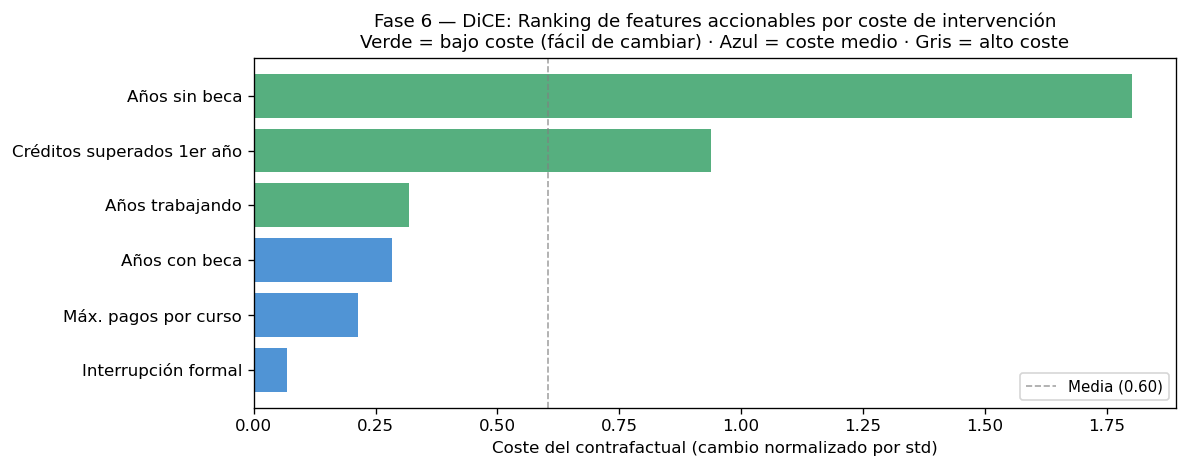

✅ Ranking accionables guardado.

Top 5 features con MENOR coste (más fáciles de intervenir):
  Interrupción formal                : coste=0.068
  Máx. pagos por curso               : coste=0.214
  Años con beca                      : coste=0.284
  Años trabajando                    : coste=0.319
  Créditos superados 1er año         : coste=0.938


In [9]:
# ============================================================
# CELDA 9: RANKING DE FEATURES ACCIONABLES POR COSTE 🏆
# Calcula cuánto tiene que cambiar cada feature accionable
# para invertir la predicción (coste del contrafactual).
# Features con menor coste = palancas de intervención prioritaria.
# Agrega sobre todos los perfiles para obtener un ranking robusto.
# ============================================================
costes_accionables = {f: [] for f in FEATURES_ACCIONABLES}

for nombre_perfil in instancias:
    if len(df_dice) == 0:
        break
    subset = df_dice[df_dice['perfil'] == nombre_perfil]
    if len(subset) < 2:
        continue
    orig_row = subset[subset['tipo'] == 'original'][FEATURES_ACCIONABLES].iloc[0]
    # Calcular delta para cada contrafactual (puede haber hasta 3)
    cfs = subset[subset['tipo'] == 'contrafactual'][FEATURES_ACCIONABLES]
    for _, cf_row in cfs.iterrows():
        delta = (cf_row - orig_row).abs()
        for f in FEATURES_ACCIONABLES:
            costes_accionables[f].append(delta[f])

# Coste medio por feature (normalizado por std para comparar escalas)
stds = X_test_prep[FEATURES_ACCIONABLES].std().replace(0, 1)
coste_medio = pd.Series({
    f: np.mean(costes_accionables[f]) / stds[f]
    if costes_accionables[f] else 0
    for f in FEATURES_ACCIONABLES
})

# Solo features que aparecen en algún contrafactual
coste_medio = coste_medio[coste_medio > 0].sort_values(ascending=False)

if len(coste_medio) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(coste_medio) * 0.4)))
    colores = ['#38a169' if i < 3 else '#3182ce' if i < 6 else '#718096'
               for i in range(len(coste_medio))]
    labels = [nombre_legible(f) for f in coste_medio.index]
    ax.barh(labels[::-1], coste_medio.values[::-1],
            color=colores[::-1], alpha=0.85)
    ax.set_xlabel('Coste del contrafactual (cambio normalizado por std)')
    ax.set_title(
        'Fase 6 — DiCE: Ranking de features accionables por coste de intervención\n'
        'Verde = bajo coste (fácil de cambiar) · Azul = coste medio · Gris = alto coste',
        fontsize=11
    )
    # Línea vertical de referencia
    ax.axvline(coste_medio.mean(), color='gray', linestyle='--',
               linewidth=1, alpha=0.7, label=f'Media ({coste_medio.mean():.2f})')
    ax.legend(fontsize=9)
    plt.tight_layout()
    ruta_accionables = DIR_RESULTS / 'dice_accionables.png'
    plt.savefig(ruta_accionables, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'✅ Ranking accionables guardado.')
    print('\nTop 5 features con MENOR coste (más fáciles de intervenir):')
    for f, coste in coste_medio.nsmallest(5).items():
        print(f'  {nombre_legible(f):35s}: coste={coste:.3f}')
else:
    print('⚠️  No hay datos suficientes para el ranking.')
    ruta_accionables = None

In [10]:
# ============================================================
# CELDA 10: GENERAR HTML
# render_pagina_desde_fichero — estándar del proyecto.
# ============================================================
def img_b64(ruta) -> str:
    if not ruta or not Path(ruta).exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_cf(nombre_perfil: str, idx, b64: str) -> str:
    pos  = X_test_prep.index.get_loc(idx)
    prob = prob_test[pos]
    img_html = (
        f'<img src="data:image/png;base64,{b64}" '
        'style="max-width:100%;border-radius:6px;box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        if b64 else
        '<p style="color:#718096;font-size:13px">Contrafactual no generado.</p>'
    )
    return (
        f'<div style="margin:28px 0;padding:20px;background:#f7fafc;'
        f'border-radius:8px;border-left:4px solid #3182ce">'
        f'<h3 style="color:#2d3748;font-size:15px;margin-bottom:6px">{nombre_perfil}</h3>'
        f'<p style="color:#718096;font-size:12px;margin-bottom:12px">'
        f'Probabilidad original: <strong>{prob:.3f}</strong></p>'
        f'{img_html}'
        f'</div>'
    )

# Lista de features accionables y no accionables para el HTML
lista_accionables = ''.join(
    f'<li style="margin:3px 0"><code>{f}</code> — {nombre_legible(f)}</li>'
    for f in FEATURES_ACCIONABLES
)
lista_no_accionables = ''.join(
    f'<li style="margin:3px 0"><code>{f}</code> — {nombre_legible(f)}</li>'
    for f in FEATURES_NO_ACCIONABLES if f in features_num
)

bloques = ''
for nombre_perfil, idx in instancias.items():
    bloques += bloque_cf(nombre_perfil, idx, graficos_b64.get(nombre_perfil, ''))

n_cf = len(df_dice[df_dice['tipo'] == 'contrafactual']) if len(df_dice) > 0 else 0

contenido = (
    '<h2 style="color:#2d3748">Fase 6 — DiCE: Contrafactuales Accionables</h2>'
    '<p style="color:#4a5568;font-size:14px;max-width:800px">'
    '¿Qué cambios mínimos en las características de un alumno harían que el modelo '
    'predijera no-abandono? Generado con DiCE (Microsoft, 2020) sobre CatBoost. '
    '<strong>Solo se modifican features accionables</strong> — variables sobre las que '
    'la universidad o el alumno pueden intervenir realmente. '
    'Las features fijas (edad, sexo, nota de selectividad...) se mantienen constantes.'
    '</p>'
    f'<p style="color:#4a5568;font-size:13px;margin-top:8px">'
    f'Contrafactuales generados: <strong>{n_cf}</strong> | '
    f'Features accionables: <strong>{len(FEATURES_ACCIONABLES)}</strong> | '
    f'Features fijas: <strong>{len([f for f in FEATURES_NO_ACCIONABLES if f in features_num])}</strong>'
    f'</p>'
    # Clasificación de features
    + '<div style="display:flex;gap:20px;margin:20px 0;flex-wrap:wrap">'
    + '<div style="flex:1;min-width:280px;padding:16px;background:#f0fff4;'
    'border-radius:8px;border-left:4px solid #38a169">'
    + '<h3 style="color:#22543d;font-size:13px;margin-bottom:8px">'
    + f'✅ Features accionables ({len(FEATURES_ACCIONABLES)})</h3>'
    + f'<ul style="font-size:12px;color:#4a5568;padding-left:16px">{lista_accionables}</ul>'
    + '</div>'
    + '<div style="flex:1;min-width:280px;padding:16px;background:#fff5f5;'
    'border-radius:8px;border-left:4px solid #e53e3e">'
    + '<h3 style="color:#742a2a;font-size:13px;margin-bottom:8px">'
    + f'🔒 Features fijas ({len([f for f in FEATURES_NO_ACCIONABLES if f in features_num])})</h3>'
    + f'<ul style="font-size:12px;color:#4a5568;padding-left:16px">{lista_no_accionables}</ul>'
    + '</div></div>'
    # Ranking accionables
    + ('<div style="margin:24px 0">'
       '<h3 style="color:#2d3748;font-size:15px">'
       '🏆 Ranking de features accionables por coste de intervención</h3>'
       f'<img src="data:image/png;base64,{img_b64(ruta_accionables)}" '
       'style="max-width:100%;border-radius:6px;box-shadow:0 2px 8px rgba(0,0,0,.1)">'
       '<p style="color:#718096;font-size:12px;margin-top:6px">'
       'Verde = bajo coste (palancas prioritarias de intervención). '
       'El coste está normalizado por la desviación estándar de cada feature '
       'para que sean comparables entre sí.</p>'
       '</div>'
       if ruta_accionables else '')
    + bloques
    + '<div style="margin-top:24px;padding:16px;background:#ebf8ff;'
    'border-left:4px solid #3182ce;border-radius:6px;font-size:13px;color:#2c5282">'
    '<strong>Interpretación:</strong> Las barras verdes muestran el valor contrafactual '
    '(solo en features accionables). Las features con menor coste de cambio son las '
    'palancas de intervención más eficientes — sobre las que la universidad debería '
    'enfocar sus programas de apoyo al estudiante.'
    '</div>'
)

html_completo = render_pagina_desde_fichero('f6_m02b_dice.ipynb', contenido)
(DIR_HTML / 'm02b_dice.html').write_text(html_completo, encoding='utf-8')
print(f'✅ HTML generado: {DIR_HTML / "m02b_dice.html"}')

✅ HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m02b_dice.html
